In [1]:
!hf auth login

^C


In [ ]:
pip install transformers datasets torch matplotlib

In [2]:
from transformers import pipeline
from datasets import load_dataset
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import time 

c:\Users\Usuario9\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Cargar datasets
dataset_emotion = load_dataset("cardiffnlp/super_tweeteval", "tweet_emotion", split="test")
dataset_topic = load_dataset("cardiffnlp/super_tweeteval", "tweet_topic", split="test")

In [4]:
# Cargar modelos y pipelines
topic_model = "cardiffnlp/twitter-roberta-base-topic-latest"
emotion_model = "cardiffnlp/twitter-roberta-base-emotion-latest"

topic_classifier = pipeline("text-classification", model=topic_model, tokenizer=topic_model, return_all_scores=False)
emotion_classifier = pipeline("text-classification", model=emotion_model, tokenizer=emotion_model, return_all_scores=False)

Device set to use cpu
c:\Users\Usuario9\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Device set to use cpu


In [5]:
# Función para clasificar todos los tweets
def clasificar_tweets(dataset, classifier, columna="text", max_tweets=500):
    textos = []
    etiquetas = []
    for i in tqdm(range(min(len(dataset), max_tweets))):
        texto = dataset[i][columna]
        try:
            resultado = classifier(texto)
            etiqueta = resultado[0]['label']
        except:
            etiqueta = "error"
        textos.append(texto)
        etiquetas.append(etiqueta)
    return textos, etiquetas

# Clasificar y contar temas
print("Clasificando temas...")
tweets_topic, temas = clasificar_tweets(dataset_topic, topic_classifier)
conteo_temas = Counter(temas)

# Clasificar y contar emociones
print("Clasificando emociones...")
tweets_emotion, emociones= clasificar_tweets(dataset_emotion, emotion_classifier)
conteo_emociones = Counter(emociones)


Clasificando temas...


100%|██████████| 500/500 [01:28<00:00,  5.66it/s]


Clasificando emociones...


100%|██████████| 500/500 [01:09<00:00,  7.23it/s]


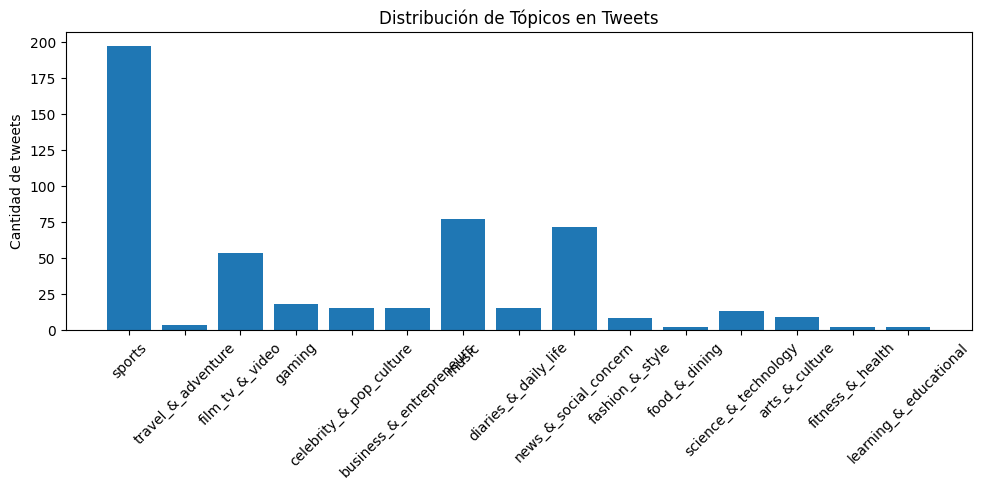

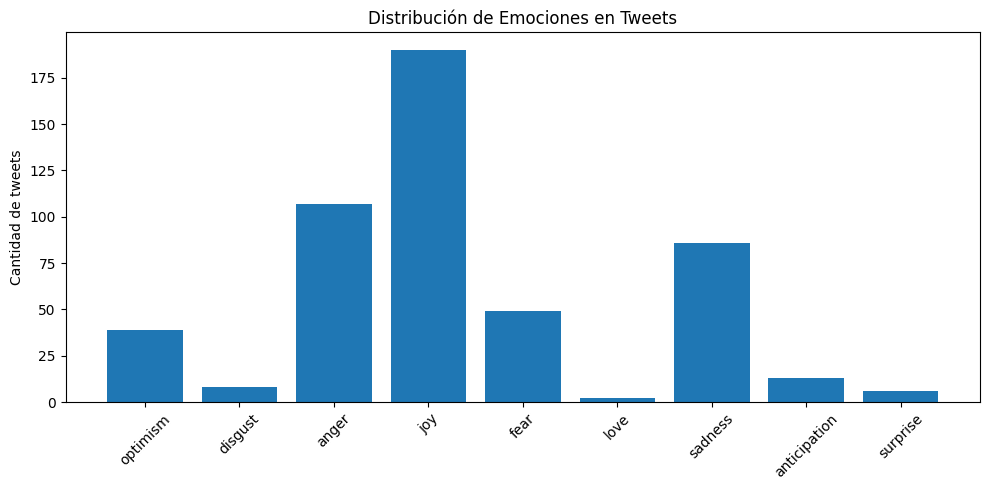

In [6]:
# Función para graficar
def graficar_conteo(conteo, titulo):
    etiquetas = list(conteo.keys())
    valores = list(conteo.values())
    plt.figure(figsize=(10, 5))
    plt.bar(etiquetas, valores)
    plt.title(titulo)
    plt.ylabel("Cantidad de tweets")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Graficar resultados
graficar_conteo(conteo_temas, "Distribución de Tópicos en Tweets")
graficar_conteo(conteo_emociones, "Distribución de Emociones en Tweets")

⏱ Tiempo de carga de datos: 14.95 s


Device set to use cpu
Device set to use cpu


⏱ Tiempo de carga de modelos: 2.51 s
Clasificando temas...


100%|██████████| 500/500 [01:33<00:00,  5.35it/s]


⏱ Tiempo de inferencia (temas): 93.43 s
Clasificando emociones...


100%|██████████| 500/500 [01:10<00:00,  7.04it/s]


⏱ Tiempo de inferencia (emociones): 70.98 s
⏱ Tiempo de agregación: 0.00 s


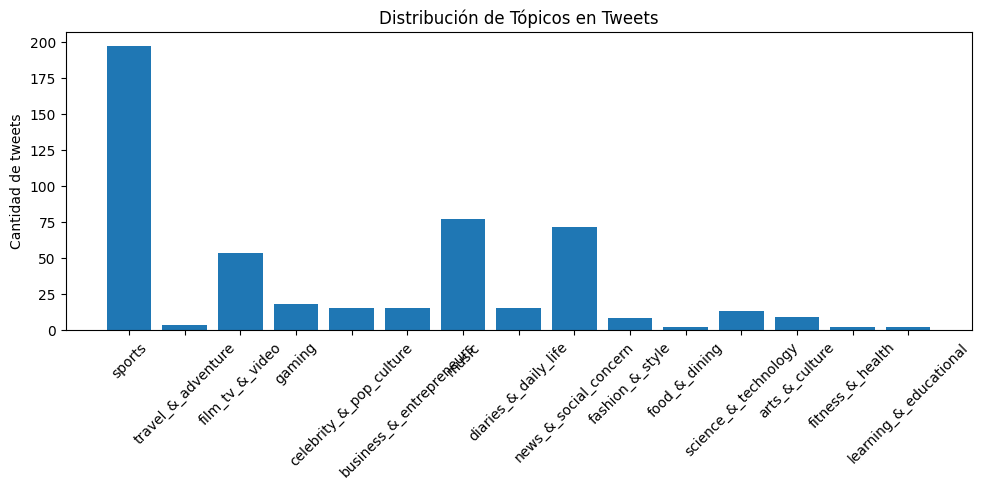

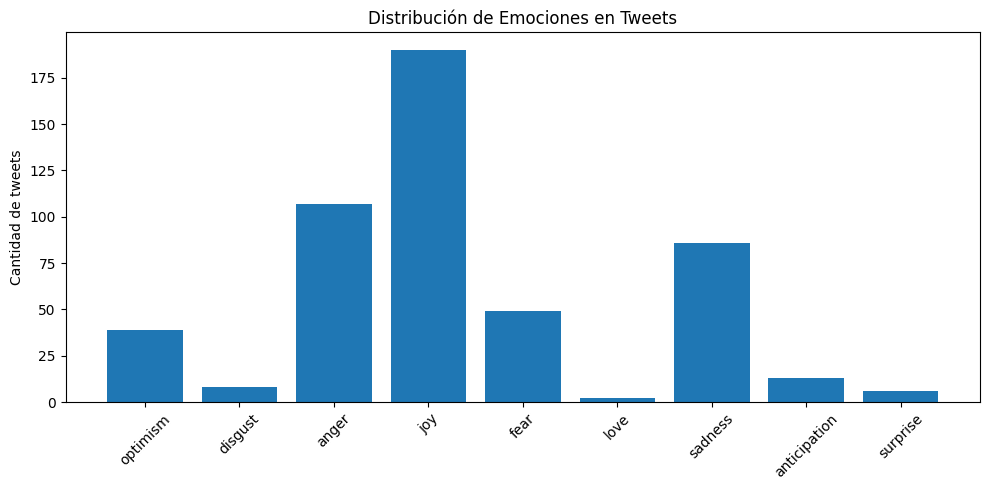

⏱ Tiempo de visualización: 0.63 s
⏱⏱ Tiempo total del pipeline: 182.50 s


In [ ]:
# ⏱ Tiempo total
start_total = time.time()

# ⏱ Tiempo de carga de datos
start = time.time()
dataset_emotion = load_dataset("cardiffnlp/super_tweeteval", "tweet_emotion", split="test")
dataset_topic = load_dataset("cardiffnlp/super_tweeteval", "tweet_topic", split="test")
end = time.time()
tiempo_datos = end - start
print(f"⏱ Tiempo de carga de datos: {tiempo_datos:.2f} s")

# ⏱ Tiempo de carga de modelos
start = time.time()
topic_model = "cardiffnlp/twitter-roberta-base-topic-latest"
emotion_model = "cardiffnlp/twitter-roberta-base-emotion-latest"
topic_classifier = pipeline("text-classification", model=topic_model, tokenizer=topic_model, return_all_scores=False)
emotion_classifier = pipeline("text-classification", model=emotion_model, tokenizer=emotion_model, return_all_scores=False)
end = time.time()
tiempo_modelos = end - start
print(f"⏱ Tiempo de carga de modelos: {tiempo_modelos:.2f} s")

# Función para clasificar
def clasificar_tweets(dataset, classifier, columna="text", max_tweets=500):
    textos = []
    etiquetas = []
    for i in tqdm(range(min(len(dataset), max_tweets))):
        texto = dataset[i][columna]
        try:
            resultado = classifier(texto)
            etiqueta = resultado[0]['label']
        except:
            etiqueta = "error"
        textos.append(texto)
        etiquetas.append(etiqueta)
    return textos, etiquetas

# ⏱ Tiempo de inferencia - temas
print("Clasificando temas...")
start = time.time()
tweets_topic, temas = clasificar_tweets(dataset_topic, topic_classifier)
end = time.time()
tiempo_inferencia_temas = end - start
print(f"⏱ Tiempo de inferencia (temas): {tiempo_inferencia_temas:.2f} s")

# ⏱ Tiempo de inferencia - emociones
print("Clasificando emociones...")
start = time.time()
tweets_emotion, emociones = clasificar_tweets(dataset_emotion, emotion_classifier)
end = time.time()
tiempo_inferencia_emociones = end - start
print(f"⏱ Tiempo de inferencia (emociones): {tiempo_inferencia_emociones:.2f} s")

# ⏱ Tiempo de agregación
start = time.time()
conteo_temas = Counter(temas)
conteo_emociones = Counter(emociones)
end = time.time()
tiempo_agregacion = end - start
print(f"⏱ Tiempo de agregación: {tiempo_agregacion:.2f} s")

# ⏱ Tiempo de visualización
start = time.time()
graficar_conteo(conteo_temas, "Distribución de Tópicos en Tweets")
graficar_conteo(conteo_emociones, "Distribución de Emociones en Tweets")
end = time.time()
tiempo_visualizacion = end - start
print(f"⏱ Tiempo de visualización: {tiempo_visualizacion:.2f} s")

# ⏱ Tiempo total
end_total = time.time()
tiempo_total = end_total - start_total
print(f"⏱⏱ Tiempo total del pipeline: {tiempo_total:.2f} s")

In [ ]:
 pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 5.7 MB/s eta 0:00:00


In [ ]:
# Filtrar solo tweets de deporte
tweets_sports = [t for t, e in zip(tweets_topic, temas) if e.lower() == "sports"]

print(f"Total tweets: {len(tweets_topic)}")
print(f"Tweets de deporte: {len(tweets_sports)}")

# Topic modeling con BERTopic
if len(tweets_sports) > 0:
    topic_model = BERTopic(language="spanish", verbose=True)
    topics, probs = topic_model.fit_transform(tweets_sports)

    # Ver info de tópicos
    df_topics = topic_model.get_topic_info()
    print(df_topics)

    # Visualizar tópicos
    fig = topic_model.visualize_barchart(top_n_topics=10)
    fig.show()

    # Graficar frecuencia
    df_count = df_topics[df_topics.Topic != -1]  # quitar outliers
    plt.bar(df_count['Topic'], df_count['Count'])
    plt.xlabel("Tópico")
    plt.ylabel("Cantidad de tweets")
    plt.title("Frecuencia de subtemas en tweets deportivos")
    plt.show()
else:
    print("No se encontraron tweets de deporte en el conjunto analizado.")

NameError: name 'tweets_topic' is not defined